In [ ]:
# Importar as bibliotecas que serão utilizadas
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
# Carregar os dados do arquivo janeiro-2024.csv
  # Alterado a codificação para ler o arquivo em UTF-8
  # Definido o delimitador de colunas do CSV
  # Removido colunas de subcabeçalho
data = pd.concat([
    pd.read_csv('janeiro-2024.csv', encoding='latin1', delimiter=';', skiprows=[0,2], nrows=744),
    pd.read_csv('fevereiro-2024.csv', encoding='latin1', delimiter=';', skiprows=[0,1,2], nrows=695),
    pd.read_csv('marco-2024.csv', encoding='latin1', delimiter=';', skiprows=[0,1,2], nrows=744)
])

# data = pd.read_csv('fevereiro-2024.csv', delimiter=';', skiprows=[0,2], nrows=695)
data['Hora'] = data['MÊS  '].str.split(" ", n = 1, expand = True)[1].str.split(":", n = 1, expand = True)[0]


In [ ]:
# Tratamento de dados

# Removendo espaçamentos indesejados
data.columns = data.columns.str.strip()

# Selecionando apenas as colunas relevantes
colunas_relevantes = [
    'Hora', 'Óxido de Enxofre', 'Óxido Nítrico', 'Dióxido de Nitrogênio',
    'Óxidos de Nitrogênio', 'Ozônio', 'Material Particulado <10µm',
    'Material Particulado <2,5µm', 'Monóxido de carbono', 'VelVento (m/s)',
    'DirVento (°)', 'T-PM10 (°C)', 'Press (mbar)', 'RadSol (W/m²)'
]

# Transformando numeros decimais em float
for coluna in colunas_relevantes:
  if data[coluna].dtype == 'object':
    data[coluna] = data[coluna].str.replace(',','.').astype(float)

# Removendo numeros inválidos
data = data.fillna(0)

# Criando um novo DataFrame com apenas as colunas relevantes
df_relevante = data[colunas_relevantes]


# **Explicação sobreas variáveis**
  * **Material Particulado:** são partículas muito finas de sólidos ou líquidos suspensos no ar. Para ser considerado PM, suas dimensões variam desde 20 μm até menos de 0,05 μm;

    * **MP <10µm:** são aquelas cujo diâmetro aerodinâmico é menor ou igual a 10 µm. Dependendo da distribuição de tamanho na faixa de 0 a 10 µm, podem ficar retidas na parte superior do sistema respiratório ou penetrar mais fundo, alcançando os alvéolos pulmonares;

    * **MP <2,5µm:** possuem diâmetro aerodinâmico menor ou igual a 2,5 µm. Por causa do seu tamanho, penetram profundamente no sistema respiratório, podendo atingir os alvéolos pulmonares;

  * **Óxido de enxofre:** provem principalmente da queima de combustíveis que contém enxofre, como óleo diesel, óleo combustível industrial e gasolina. É um dos principais formadores da chuva ácida. O dióxido de enxofre pode reagir com outras substâncias presentes no ar formando partículas de sulfato que são responsáveis pela redução da visibilidade na atmosfera;

  * **Óxidos de nitrogênio:** São formados durante processos de combustão. Em grandes cidades, os veículos geralmente são os principais responsáveis pela emissão dos óxidos de nitrogênio. O NO, sob a ação de luz solar se transforma em NO2 tem papel importante na formação de oxidantes fotoquímicos como o ozônio. Dependendo das concentrações, o NO2 causa prejuízos à saúde.

  * **Ozônio:** “Oxidantes fotoquímicos” é a denominação que se dá à mistura de poluentes secundários formados por reações entre os óxidos de nitrogênio e compostos orgânicos voláteis, na presença de luz solar, sendo estes últimos liberados na queima incompleta e evaporação de combustíveis e solventes. O principal produto dessa reação é o ozônio, por isso mesmo utilizado como parâmetro indicador da presença de oxidantes fotoquímicos na atmosfera. Tais poluentes formam a chamada névoa fotoquímica ou “smog fotoquímico”, que possui esse nome porque causa na atmosfera diminuição da visibilidade. Além de prejuízos à saúde, o ozônio pode causar danos à vegetação;

  * **Monóxido de carbono:** um gás incolor e inodoro que resulta da queima incompleta de combustíveis de origem orgânica (combustíveis fósseis, biomassa etc.). Em geral é encontrado em maiores concentrações nas cidades, emitido principalmente por veículos automotores. Altas concentrações de CO são encontradas em áreas de intensa circulação de veículos;

  * **Condições metereológicas:** a concentração de poluentes está fortemente relacionada às condições meteorológicas. Alguns dos parâmetros que favorecem altos índices de poluição são: alta porcentagem de calmaria, ventos fracos e inversões térmicas a baixa altitude. Esse fenômeno é particularmente comum no inverno paulista, quando as noites são frias e a temperatura tende a se elevar rapidamente durante o dia, provocando alteração no resfriamento natural do ar. A inversão térmica se caracteriza por uma camada de ar quente que se forma sobre a cidade, “aprisionando” o ar e impedindo a dispersão dos poluentes.



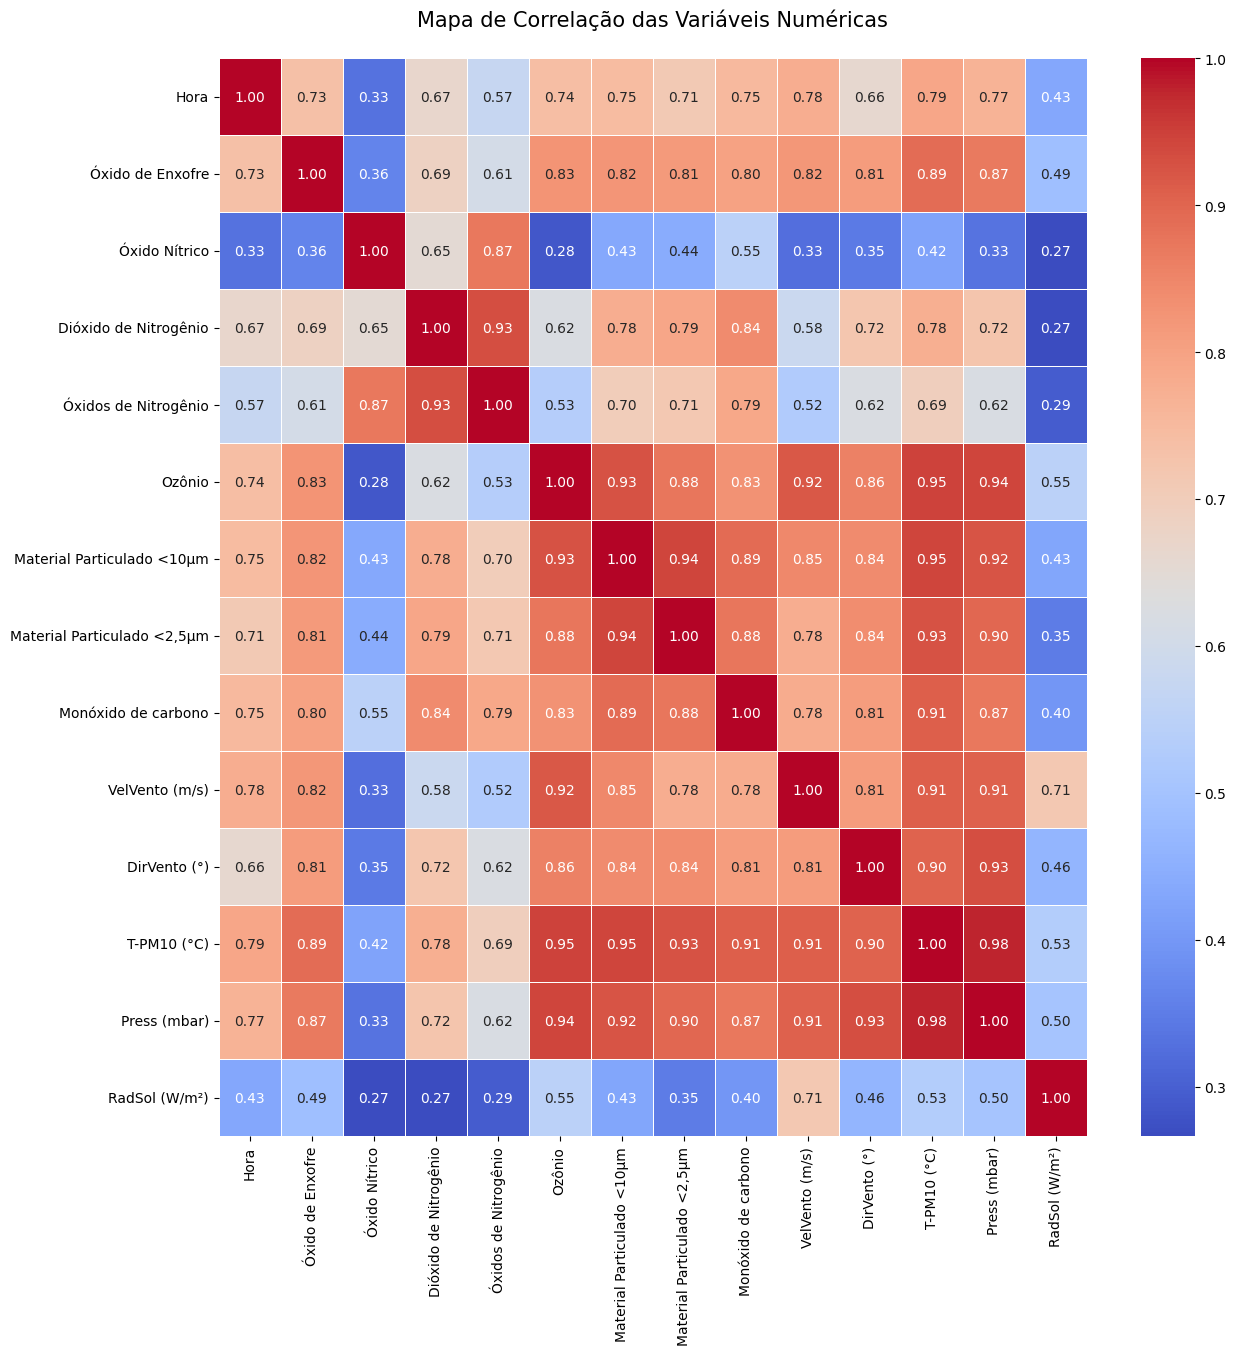

In [ ]:
# Calculando a matriz de correlação
correlation_matrix_relevante = df_relevante.corr()

plt.figure(figsize = (df_relevante.shape[1],df_relevante.shape[1]))
sns.heatmap(correlation_matrix_relevante, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Mapa de Correlação das Variáveis Numéricas\n", fontsize = 15)
plt.show()

In [ ]:
# Aplicar a redução de dimensionalidade (PCA)

# Normalizar os dados
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_relevante)

# Definir o número de componentes principais
components_number = 3

# Aplicar a técnica de Redução de Dimensionalidade (PCA)
pca = PCA(n_components=components_number)
data_reduced = pca.fit_transform(data_scaled)

# Plotar a taxa de variância explicada por cada componente principal
print(sum(pca.explained_variance_ratio_))

0.9078765301461452


Text(0.5, 1.0, 'Número de componentes vs. Taxa de variância explicada')

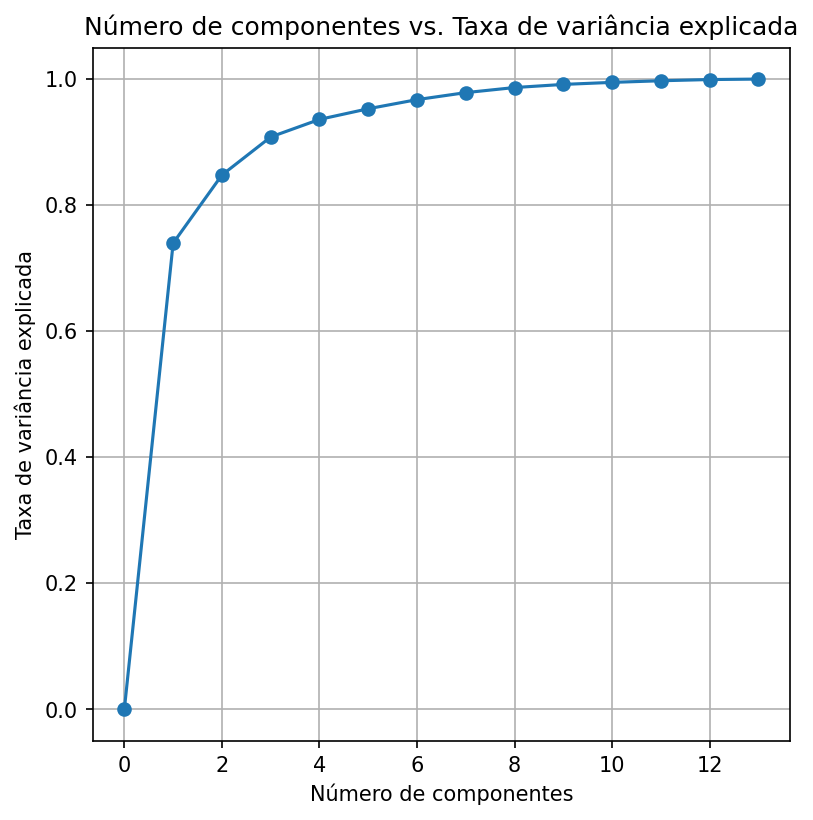

In [ ]:
# Testar variância capturada por componente
nums = np.arange(data_scaled.shape[1])

var_ratio = []
for num in nums:
  pca = PCA(n_components=num)
  pca.fit(data_scaled)
  var_ratio.append(np.sum(pca.explained_variance_ratio_))

plt.figure(figsize=(6,6),dpi=150)
plt.grid()
plt.plot(nums,var_ratio,marker='o')
plt.xlabel('Número de componentes')
plt.ylabel('Taxa de variância explicada')
plt.title('Número de componentes vs. Taxa de variância explicada')

In [ ]:
# Aplicar um modelo de agrupamento (K-means)

# Definir o número de clusters
cluster_number = 5

kmeans = KMeans(n_clusters=cluster_number, n_init='auto', random_state = 0,)
clusters = kmeans.fit_predict(data_reduced)

# Adicionar as informações de cluster aos dados reduzidos
k_groups = [f'Grupo {i+1}' for i in range(components_number)]

data_reduced_with_clusters = pd.DataFrame(data_reduced, columns=k_groups)
data_reduced_with_clusters['Cluster'] = clusters

# Separar as features e o target (considerando que a coluna 'Cluster' é o target para a rede neural)
X = data_reduced_with_clusters[k_groups]
y = data_reduced_with_clusters['Cluster']

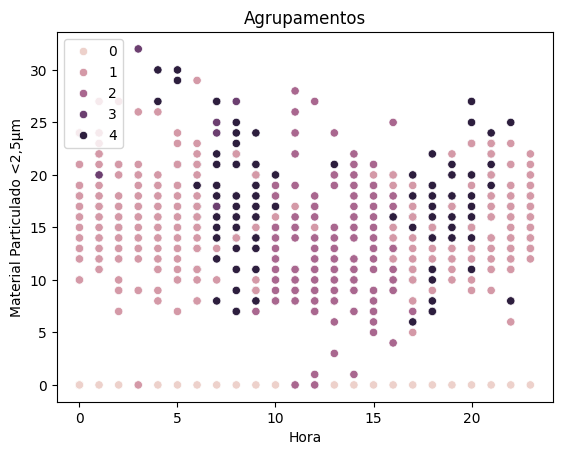

In [ ]:
# Gráfico para exibir classificação por agrupamento
sns.scatterplot(data = df_relevante, x = 'Hora', y = 'Material Particulado <2,5µm', hue = kmeans.labels_)
plt.title('Agrupamentos')
plt.show()

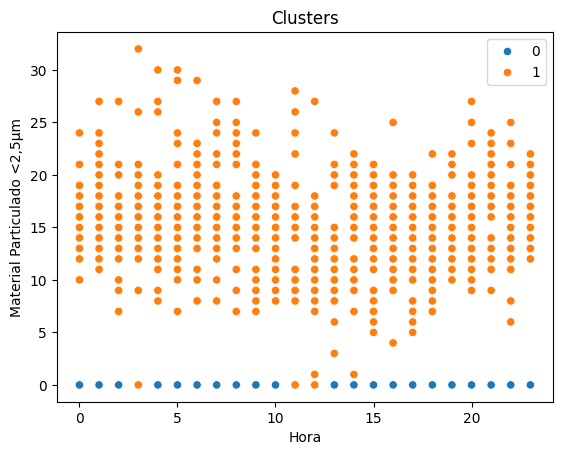

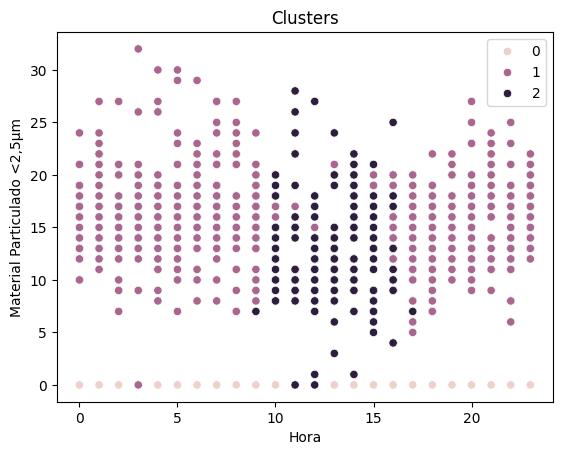

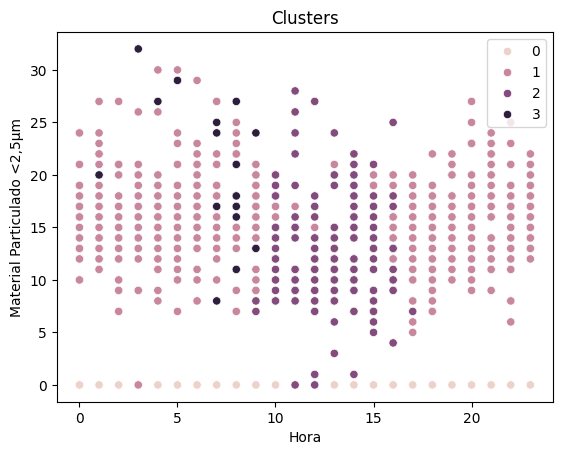

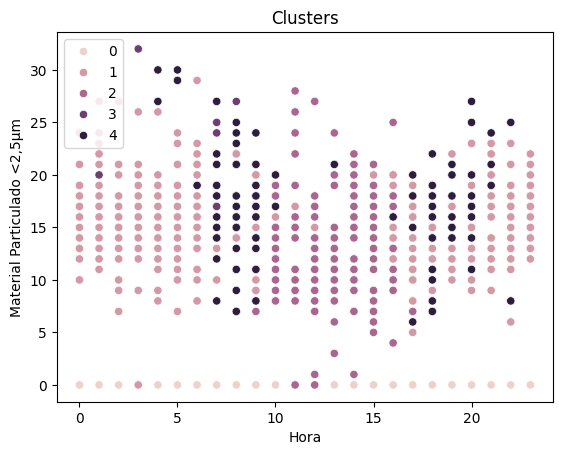

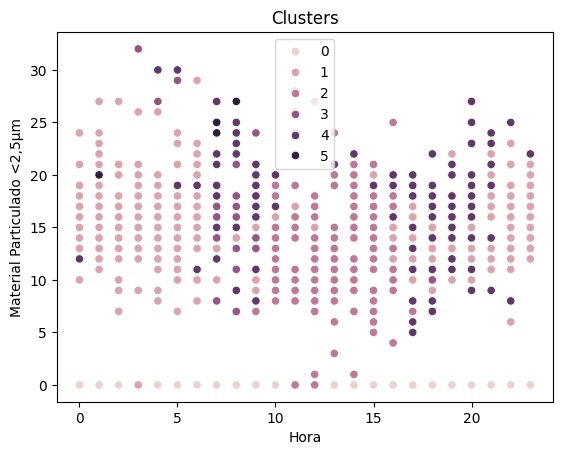

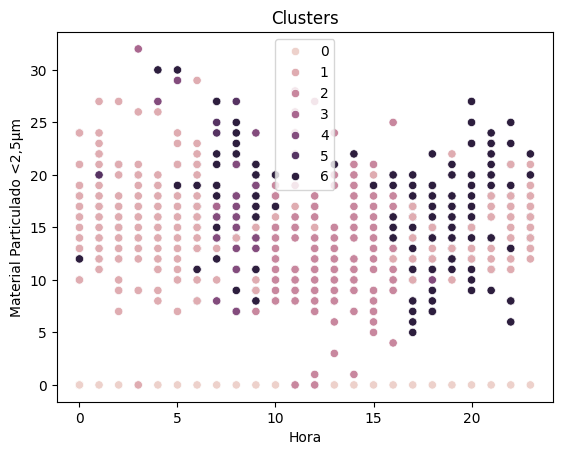

In [ ]:
K = range(2, 8)
fits = []
score = []


for k in K:
    model = KMeans(n_clusters = k, random_state = 0, n_init='auto').fit(data_reduced)

    fits.append(model)

    score.append(silhouette_score(data_reduced, model.labels_, metric='euclidean'))

for i in range(len(fits)):
    sns.scatterplot(data = df_relevante, x = 'Hora', y = 'Material Particulado <2,5µm', hue = fits[i].labels_)
    plt.title('Clusters')
    plt.show()

In [ ]:
# Conjuntos de treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(data_reduced, y, test_size=0.3, random_state=42)

# Treinamento do MLP
mlp = MLPClassifier(hidden_layer_sizes=(25, 25), max_iter=1000)
mlp.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(25, 25), max_iter=1000)

In [ ]:
# Previsão
predictions_mlp = mlp.predict(X_test)

# Acurácia
accuracy_mlp = accuracy_score(y_test, predictions_mlp)
print(f'Acurácia (MLP): {accuracy_mlp}')


Acurácia (MLP): 0.9954198473282443
